# Lab 5
#### MCA-A
#### 2547112

In [1]:
import numpy as np
import matplotlib.pyplot as plt 

from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler

## Load the Dataset

In [2]:
diabetes = load_diabetes()

X = diabetes.data[:, [2]]

y = diabetes.target

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (442, 1)
Shape of y: (442,)


# Standardize the Features

In [3]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[ 1.29708846]
 [-1.08218016]
 [ 0.93453324]
 [-0.24377122]
 [-0.76494435]]


## Setting Params

In [4]:
# Init values for slope and intercept
m = 0.0
c = 0.0

# hyperparameters
learning_rate = 0.05
iterations = 1000

# Store loss values
loss_history = []

## Gradient Descent

In [5]:
for i in range(iterations):
    y_pred = m * X_scaled.flatten() + c
    error = y_pred - y 
    loss = np.mean(error ** 2)
    loss_history.append(loss)
    dm = (2 / len(X_scaled)) * np.dot(error, X_scaled.flatten())
    dc = (2 / len(X_scaled)) * np.sum(error)
    
    m -= learning_rate * dm
    c -= learning_rate * dc 
    
    if i % 100 == 0:
        print(f"Iteration {i}: Loss = {loss:.4f}, m = {m:.4f}, c = {c:.4f}")
        

Iteration 0: Loss = 29074.4819, m = 4.5160, c = 15.2133
Iteration 100: Loss = 3890.4566, m = 45.1590, c = 152.1298
Iteration 200: Loss = 3890.4566, m = 45.1600, c = 152.1335
Iteration 300: Loss = 3890.4566, m = 45.1600, c = 152.1335
Iteration 400: Loss = 3890.4566, m = 45.1600, c = 152.1335
Iteration 500: Loss = 3890.4566, m = 45.1600, c = 152.1335
Iteration 600: Loss = 3890.4566, m = 45.1600, c = 152.1335
Iteration 700: Loss = 3890.4566, m = 45.1600, c = 152.1335
Iteration 800: Loss = 3890.4566, m = 45.1600, c = 152.1335
Iteration 900: Loss = 3890.4566, m = 45.1600, c = 152.1335


## Print Final Parameters

In [6]:
print(f"\nFinal Parameters:\n\tSlope (m): {m:.4f}\n\tIntercept (c): {c:.4f}")


Final Parameters:
	Slope (m): 45.1600
	Intercept (c): 152.1335


## Plot the Regression Line

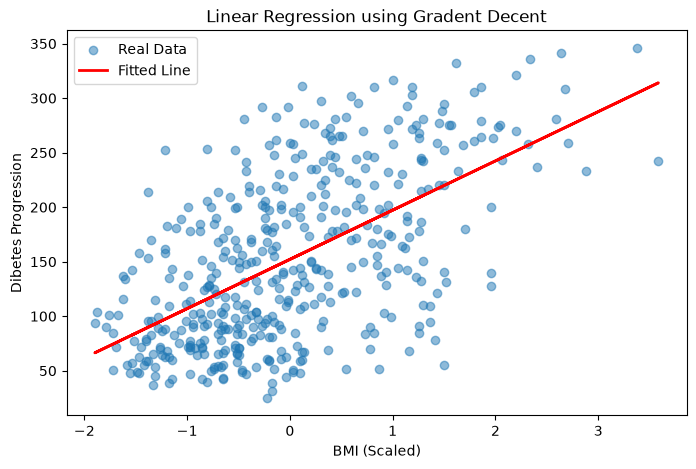

In [7]:
plt.figure(figsize=(8, 5))

plt.scatter(X_scaled, y, alpha=0.5, label='Real Data')

plt.plot(X_scaled, m * X_scaled.flatten() + c, color = 'red', linewidth = 2, label="Fitted Line")

plt.xlabel("BMI (Scaled)")
plt.ylabel("Dibetes Progression")
plt.title("Linear Regression using Gradent Decent")
plt.legend()
plt.show()

## Plot the Loss Curve

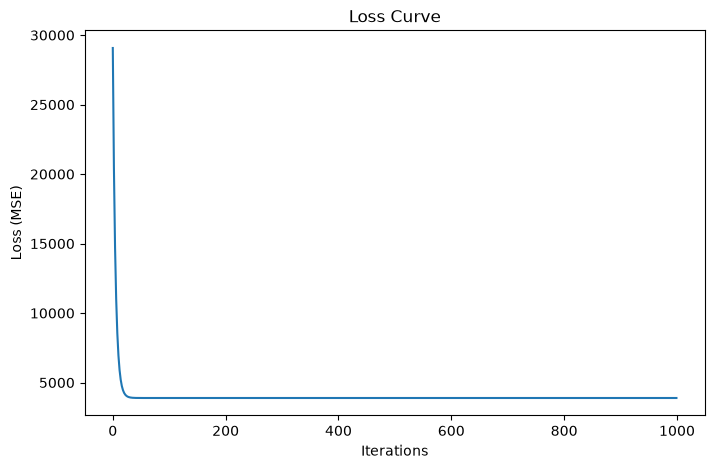

In [8]:
plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.xlabel("Iterations")
plt.ylabel("Loss (MSE)")
plt.title("Loss Curve")
plt.show()

## 3D Visualization of the Initial Gradient Descent Path

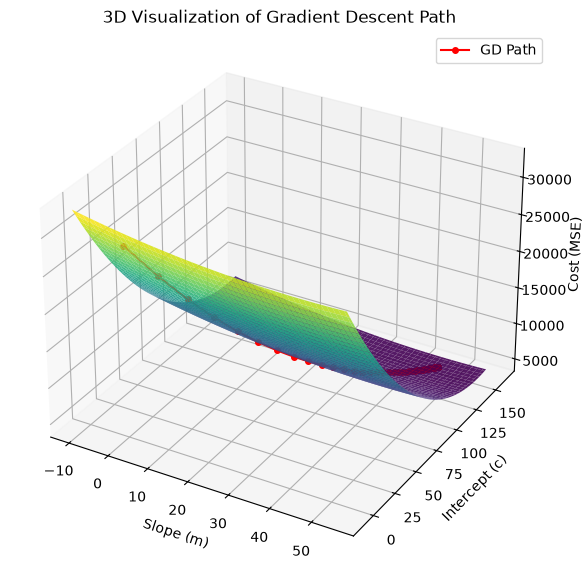

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler

# Redefine the compute_cost_single function to ensure it's available
def compute_cost_single(m_val, c_val, X_data, y_data):
    predictions = m_val * X_data.flatten() + c_val
    return np.mean((predictions - y_data) ** 2)

# --- Data Loading and Scaling (added for self-containment) ---
diabetes = load_diabetes()
X = diabetes.data[:, [2]]
y = diabetes.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# ----------------------------------------------------------------

m_viz = 0.0
c_viz = 0.0
learning_rate_viz = 0.05
iterations_viz = 1000

m_history = []
c_history = []
loss_history_viz = []

for i in range(iterations_viz):
    y_pred = m_viz * X_scaled.flatten() + c_viz
    error = y_pred - y
    loss = np.mean(error ** 2)

    m_history.append(m_viz)
    c_history.append(c_viz)
    loss_history_viz.append(loss)

    dm = (2 / len(X_scaled)) * np.dot(error, X_scaled.flatten())
    dc = (2 / len(X_scaled)) * np.sum(error)

    m_viz -= learning_rate_viz * dm
    c_viz -= learning_rate_viz * dc

# Create the cost surface for m and c (re-using the ranges from before)
# Adjusting ranges dynamically based on the history for better visualization
m_vals = np.linspace(min(m_history) - 10, max(m_history) + 10, 100)
c_vals = np.linspace(min(c_history) - 10, max(c_history) + 10, 100)
M, C = np.meshgrid(m_vals, c_vals)

# Calculate J_vals for the surface
J = np.array([compute_cost_single(mv, cv, X_scaled, y) for mv, cv in zip(M.flatten(), C.flatten())]).reshape(M.shape)

# 3D Visualization
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(M, C, J, cmap='viridis', alpha=0.9)

# Plot the path of gradient descent
ax.plot(m_history, c_history, loss_history_viz, color='red', marker='o', markersize=4, label='GD Path')

ax.set_xlabel('Slope (m)')
ax.set_ylabel('Intercept (c)')
ax.set_zlabel('Cost (MSE)')
ax.set_title('3D Visualization of Gradient Descent Path')
ax.legend()
plt.show()

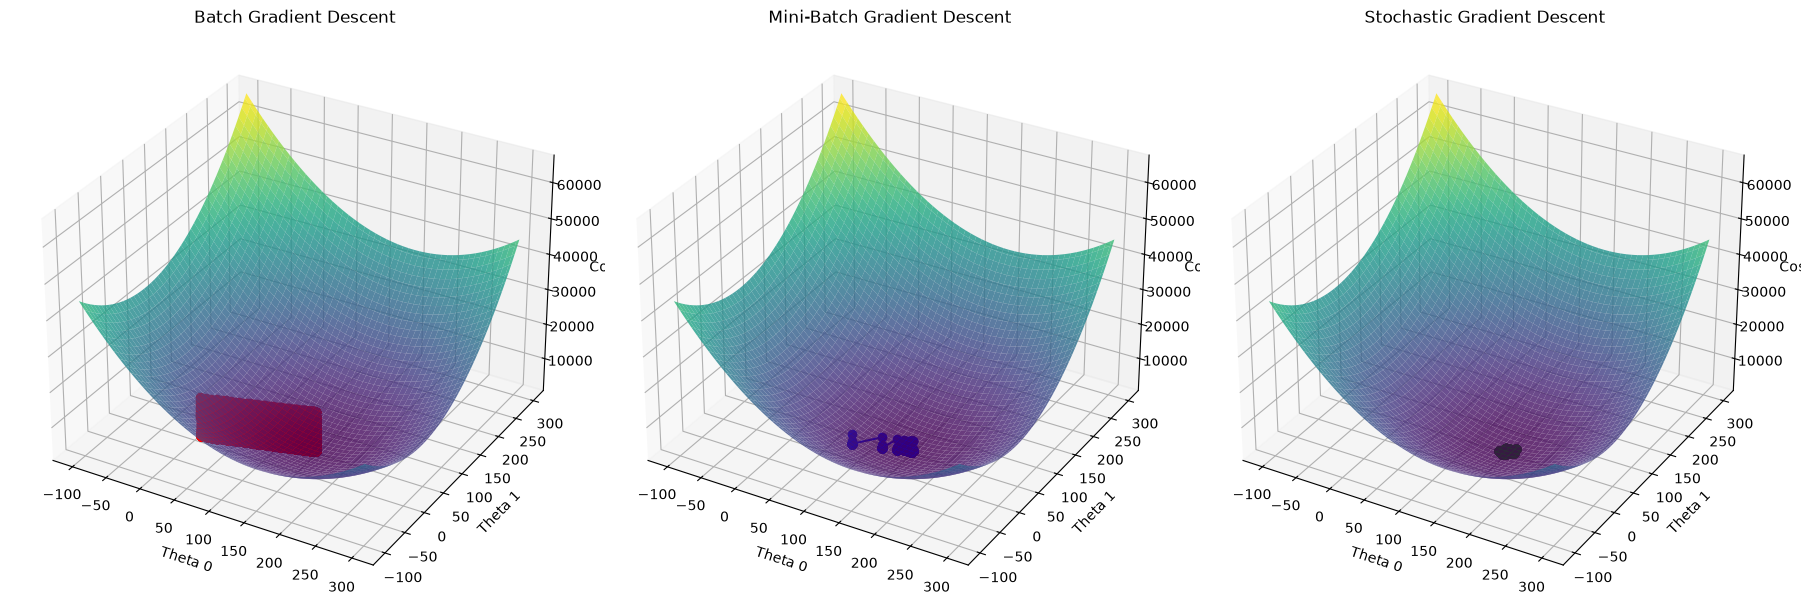

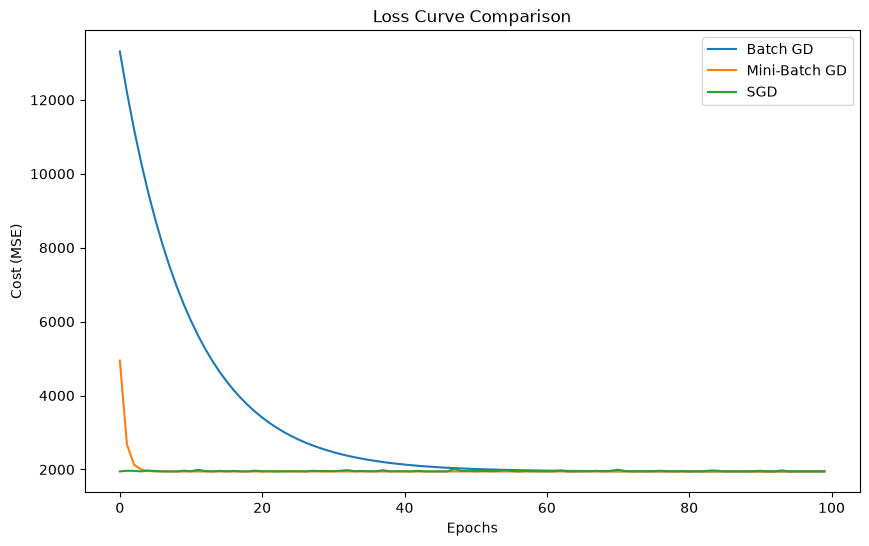

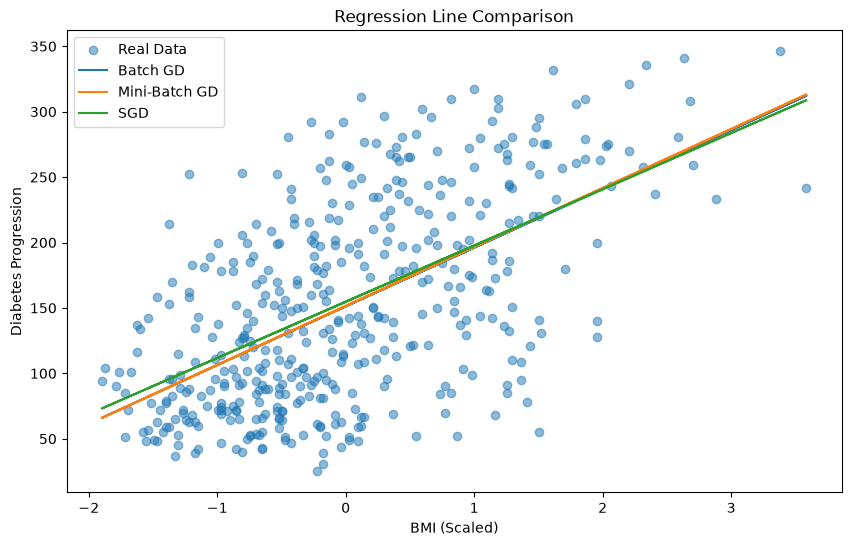


FINAL PARAMETERS

Batch GD
[[151.23277342]
 [ 44.89265874]]

Mini-Batch GD
[[151.51760811]
 [ 45.08603303]]

Stochastic GD
[[154.71996151]
 [ 42.97517692]]


In [10]:
# =========================================================
# COMPARISON OF:
# 1. Batch Gradient Descent
# 2. Mini-Batch Gradient Descent
# 3. Stochastic Gradient Descent
# USING DIABETES DATASET
# WITH 3D VISUALIZATION
# =========================================================

import numpy as np
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D

from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler

# =========================================================
# STEP 1 — LOAD DATASET
# =========================================================

diabetes = load_diabetes()

# Use only one feature (BMI)
X = diabetes.data[:, [2]]

# Target
y = diabetes.target.reshape(-1, 1)

# Scale feature
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

m = len(X_scaled)

# Add bias column
X_bias = np.c_[np.ones((m, 1)), X_scaled]

# =========================================================
# STEP 2 — COST FUNCTION
# =========================================================

def compute_cost(theta, X, y):

    predictions = X.dot(theta)

    return (1 / (2 * len(y))) * np.sum((predictions - y) ** 2)

# =========================================================
# STEP 3 — BATCH GRADIENT DESCENT
# =========================================================

def batch_gradient_descent(X, y,
                           learning_rate=0.05,
                           epochs=100):

    theta = np.zeros((2, 1))

    history = []

    cost_history = []

    m = len(y)

    for epoch in range(epochs):

        predictions = X.dot(theta)

        gradients = (1 / m) * X.T.dot(predictions - y)

        theta = theta - learning_rate * gradients

        history.append(theta.copy())

        cost = compute_cost(theta, X, y)

        cost_history.append(cost)

    return theta, np.array(history), cost_history

# =========================================================
# STEP 4 — MINI-BATCH GRADIENT DESCENT
# =========================================================

def mini_batch_gradient_descent(X, y,
                                learning_rate=0.05,
                                epochs=100,
                                batch_size=32):

    theta = np.zeros((2, 1))

    history = []

    cost_history = []

    m = len(y)

    for epoch in range(epochs):

        indices = np.random.permutation(m)

        X_shuffled = X[indices]

        y_shuffled = y[indices]

        for i in range(0, m, batch_size):

            X_batch = X_shuffled[i:i + batch_size]

            y_batch = y_shuffled[i:i + batch_size]

            predictions = X_batch.dot(theta)

            gradients = (1 / len(X_batch)) * \
                        X_batch.T.dot(predictions - y_batch)

            theta = theta - learning_rate * gradients

        history.append(theta.copy())

        cost = compute_cost(theta, X, y)

        cost_history.append(cost)

    return theta, np.array(history), cost_history

# =========================================================
# STEP 5 — STOCHASTIC GRADIENT DESCENT
# =========================================================

def stochastic_gradient_descent(X, y,
                                learning_rate=0.01,
                                epochs=100):

    theta = np.zeros((2, 1))

    history = []

    cost_history = []

    m = len(y)

    for epoch in range(epochs):

        indices = np.random.permutation(m)

        X_shuffled = X[indices]

        y_shuffled = y[indices]

        for i in range(m):

            xi = X_shuffled[i:i+1]

            yi = y_shuffled[i:i+1]

            predictions = xi.dot(theta)

            gradients = xi.T.dot(predictions - yi)

            theta = theta - learning_rate * gradients

        history.append(theta.copy())

        cost = compute_cost(theta, X, y)

        cost_history.append(cost)

    return theta, np.array(history), cost_history

# =========================================================
# STEP 6 — TRAIN ALL MODELS
# =========================================================

theta_batch, history_batch, cost_batch = \
    batch_gradient_descent(X_bias, y)

theta_mini, history_mini, cost_mini = \
    mini_batch_gradient_descent(X_bias, y)

theta_sgd, history_sgd, cost_sgd = \
    stochastic_gradient_descent(X_bias, y)

# =========================================================
# STEP 7 — CREATE COST SURFACE
# =========================================================

theta0_vals = np.linspace(-100, 300, 100)

theta1_vals = np.linspace(-100, 300, 100)

T0, T1 = np.meshgrid(theta0_vals, theta1_vals)

J_vals = np.zeros(T0.shape)

for i in range(T0.shape[0]):

    for j in range(T0.shape[1]):

        theta_temp = np.array([[T0[i, j]],
                               [T1[i, j]]])

        J_vals[i, j] = compute_cost(theta_temp,
                                    X_bias,
                                    y)

# =========================================================
# STEP 8 — 3D VISUALIZATION
# =========================================================

fig = plt.figure(figsize=(18, 6))

# -----------------------------
# BATCH GD
# -----------------------------

ax1 = fig.add_subplot(131, projection='3d')

ax1.plot_surface(T0, T1, J_vals,
                 cmap='viridis',
                 alpha=0.8)

ax1.plot(history_batch[:, 0],
         history_batch[:, 1],
         [compute_cost(h.reshape(2,1), X_bias, y)
          for h in history_batch],
         color='red',
         marker='o')

ax1.set_title("Batch Gradient Descent")

ax1.set_xlabel("Theta 0")

ax1.set_ylabel("Theta 1")

ax1.set_zlabel("Cost")

# -----------------------------
# MINI-BATCH GD
# -----------------------------

ax2 = fig.add_subplot(132, projection='3d')

ax2.plot_surface(T0, T1, J_vals,
                 cmap='viridis',
                 alpha=0.8)

ax2.plot(history_mini[:, 0],
         history_mini[:, 1],
         [compute_cost(h.reshape(2,1), X_bias, y)
          for h in history_mini],
         color='blue',
         marker='o')

ax2.set_title("Mini-Batch Gradient Descent")

ax2.set_xlabel("Theta 0")

ax2.set_ylabel("Theta 1")

ax2.set_zlabel("Cost")

# -----------------------------
# SGD
# -----------------------------

ax3 = fig.add_subplot(133, projection='3d')

ax3.plot_surface(T0, T1, J_vals,
                 cmap='viridis',
                 alpha=0.8)

ax3.plot(history_sgd[:, 0],
         history_sgd[:, 1],
         [compute_cost(h.reshape(2,1), X_bias, y)
          for h in history_sgd],
         color='green',
         marker='o')

ax3.set_title("Stochastic Gradient Descent")

ax3.set_xlabel("Theta 0")

ax3.set_ylabel("Theta 1")

ax3.set_zlabel("Cost")

plt.tight_layout()

plt.show()

# =========================================================
# STEP 9 — LOSS CURVE COMPARISON
# =========================================================

plt.figure(figsize=(10, 6))

plt.plot(cost_batch,
         label="Batch GD")

plt.plot(cost_mini,
         label="Mini-Batch GD")

plt.plot(cost_sgd,
         label="SGD")

plt.xlabel("Epochs")

plt.ylabel("Cost (MSE)")

plt.title("Loss Curve Comparison")

plt.legend()

plt.show()

# =========================================================
# STEP 10 — REGRESSION LINE COMPARISON
# =========================================================

plt.figure(figsize=(10, 6))

plt.scatter(X_scaled,
            y,
            alpha=0.5,
            label="Real Data")

# Batch GD line
plt.plot(X_scaled,
         X_bias.dot(theta_batch),
         label="Batch GD")

# Mini-Batch GD line
plt.plot(X_scaled,
         X_bias.dot(theta_mini),
         label="Mini-Batch GD")

# SGD line
plt.plot(X_scaled,
         X_bias.dot(theta_sgd),
         label="SGD")

plt.xlabel("BMI (Scaled)")

plt.ylabel("Diabetes Progression")

plt.title("Regression Line Comparison")

plt.legend()

plt.show()

# =========================================================
# STEP 11 — FINAL PARAMETERS
# 3D Visualization of the Initial Gradient Descent Path=========================================================

print("\n==============================")
print("FINAL PARAMETERS")
print("==============================")

print("\nBatch GD")
print(theta_batch)

print("\nMini-Batch GD")
print(theta_mini)

print("\nStochastic GD")
print(theta_sgd)

---

# Lab Experiment 5 : Linear Regression through Gradient Descent

## Aim
To implement Linear Regression using the Gradient Descent optimization algorithm and evaluate its performance on the **Student Performance** dataset (UCI Machine Learning Repository).

## Dataset
- **Name:** Student Performance Dataset
- **Source:** https://archive.ics.uci.edu/dataset/320/student+performance
- **File used:** `student-mat.csv` (Math course), 395 students, 33 attributes
- **Target:** `G3` - final grade (0-20)


## 1. Load the Dataset

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

DATA_PATH = "student-mat.csv"

df = pd.read_csv(DATA_PATH, sep=";")

print(f"Shape: {df.shape}")
df.head()

Shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## 2. Data Preprocessing

### 2.1 Check for Missing Values

In [12]:
print(df.isnull().sum().sum(), "missing values in the dataset")
df.info()

0 missing values in the dataset
<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher     

### 2.2 Encode Categorical Variables

The dataset has three kinds of categorical columns:
- **Binary yes/no** columns (`schoolsup`, `famsup`, `paid`, `activities`, `nursery`, `higher`, `internet`, `romantic`) -> mapped to 0/1
- **Binary nominal** columns (`school`, `sex`, `address`, `famsize`, `Pstatus`) -> mapped to 0/1
- **Multi-class nominal** columns (`Mjob`, `Fjob`, `reason`, `guardian`) -> one-hot encoded

In [13]:
df_enc = df.copy()

binary_yes_no = ["schoolsup", "famsup", "paid", "activities",
                  "nursery", "higher", "internet", "romantic"]
for col in binary_yes_no:
    df_enc[col] = df_enc[col].map({"yes": 1, "no": 0})

binary_map = {
    "school": {"GP": 0, "MS": 1},
    "sex": {"F": 0, "M": 1},
    "address": {"U": 0, "R": 1},
    "famsize": {"LE3": 0, "GT3": 1},
    "Pstatus": {"T": 0, "A": 1},
}
for col, mapping in binary_map.items():
    df_enc[col] = df_enc[col].map(mapping)

nominal_cols = ["Mjob", "Fjob", "reason", "guardian"]
df_enc = pd.get_dummies(df_enc, columns=nominal_cols, drop_first=True)

# Convert any remaining booleans (from get_dummies) to int
bool_cols = df_enc.select_dtypes(include="bool").columns
df_enc[bool_cols] = df_enc[bool_cols].astype(int)

print(f"Shape after encoding: {df_enc.shape}")
df_enc.head()

Shape after encoding: (395, 42)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,Mjob_teacher,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other
0,0,0,18,0,1,1,4,4,2,2,...,0,0,0,0,1,0,0,0,1,0
1,0,0,17,0,1,0,1,1,1,2,...,0,0,1,0,0,0,0,0,0,0
2,0,0,15,0,0,0,1,1,1,2,...,0,0,1,0,0,0,1,0,1,0
3,0,0,15,0,1,0,4,2,1,3,...,0,0,0,1,0,1,0,0,1,0
4,0,0,16,0,1,0,3,3,1,2,...,0,0,1,0,0,1,0,0,0,0


## 3. Feature Selection & Target Variable

`G3` (final grade) is the target. All remaining columns are used as input features,
including the period grades `G1` and `G2` (as provided by the dataset).

In [14]:
X = df_enc.drop(columns=["G3"]).values.astype(float)
y = df_enc["G3"].values.astype(float)

feature_names = df_enc.drop(columns=["G3"]).columns.tolist()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (395, 41)
y shape: (395,)


## 4. Train-Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")

Train set: (316, 41), Test set: (79, 41)


## 5. Feature Scaling

The scaler is fit only on the training data and then used to transform both
the training and test sets, to avoid data leakage.

In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Add bias (intercept) column
X_train_bias = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
X_test_bias = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]

print(f"X_train_bias shape: {X_train_bias.shape}")

X_train_bias shape: (316, 42)


## 6. Implement Linear Regression using Gradient Descent

A vectorized, multivariate version of the same Batch Gradient Descent approach
used earlier on the diabetes dataset, generalized to `n` features.

In [17]:
def compute_cost(theta, X, y):
    m = len(y)
    predictions = X.dot(theta)
    return (1 / (2 * m)) * np.sum((predictions - y) ** 2)


def batch_gradient_descent(X, y, learning_rate=0.05, iterations=1000):
    m, n = X.shape
    theta = np.zeros(n)
    cost_history = []

    for i in range(iterations):
        predictions = X.dot(theta)
        error = predictions - y
        gradients = (1 / m) * X.T.dot(error)
        theta = theta - learning_rate * gradients
        cost_history.append(compute_cost(theta, X, y))

    return theta, cost_history

In [18]:
learning_rate = 0.1
iterations = 1000

theta, cost_history = batch_gradient_descent(
    X_train_bias, y_train, learning_rate=learning_rate, iterations=iterations
)

print(f"Final training cost: {cost_history[-1]:.4f}")
print(f"Intercept: {theta[0]:.4f}")

Final training cost: 1.4115
Intercept: 10.3259


## 7. Effect of Learning Rate on Convergence

Different learning rates are compared over a fixed number of iterations to
observe their effect on convergence speed and stability.

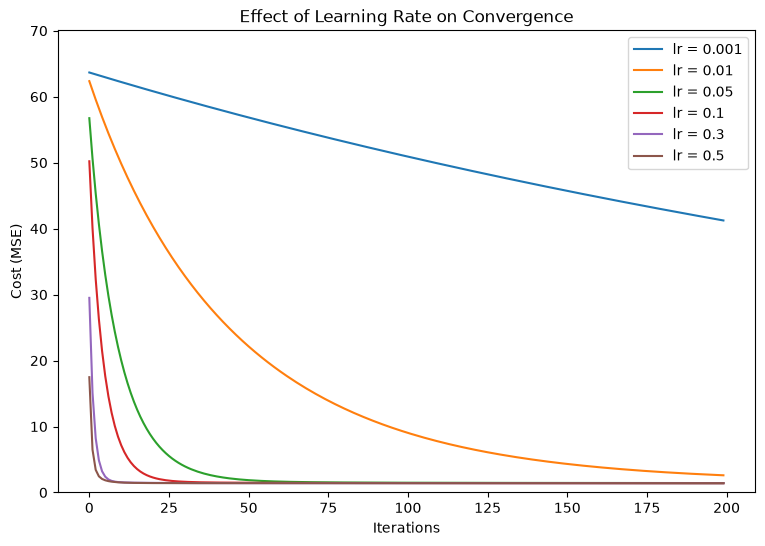

In [19]:
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.3, 0.5]
lr_histories = {}

for lr in learning_rates:
    _, history = batch_gradient_descent(X_train_bias, y_train, learning_rate=lr, iterations=200)
    lr_histories[lr] = history

plt.figure(figsize=(9, 6))
for lr, history in lr_histories.items():
    plt.plot(history, label=f"lr = {lr}")

plt.xlabel("Iterations")
plt.ylabel("Cost (MSE)")
plt.title("Effect of Learning Rate on Convergence")
plt.legend()
plt.ylim(0, lr_histories[learning_rates[0]][0] * 1.1)
plt.show()

Very small learning rates (e.g. `0.001`) converge slowly and would need many
more iterations to reach the minimum. Moderate rates (`0.05` - `0.3`) converge
quickly and smoothly. Very large learning rates (e.g. `0.5`) can overshoot the
minimum and oscillate or diverge, which is visible as a spike or instability in
the corresponding curve.

## 8. Loss (Cost) vs Iterations - Chosen Model

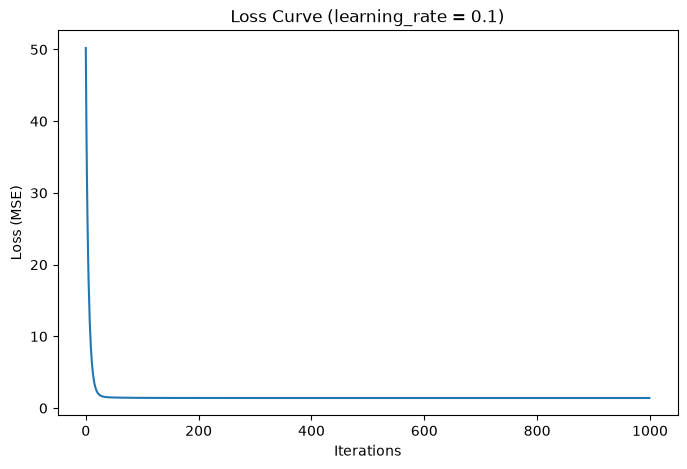

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(cost_history)
plt.xlabel("Iterations")
plt.ylabel("Loss (MSE)")
plt.title(f"Loss Curve (learning_rate = {learning_rate})")
plt.show()

## 9. Model Evaluation on Test Set

In [21]:
y_pred = X_test_bias.dot(theta)

mae = np.mean(np.abs(y_test - y_pred))
mse = np.mean((y_test - y_pred) ** 2)
rmse = np.sqrt(mse)

ss_res = np.sum((y_test - y_pred) ** 2)
ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ss_res / ss_tot)

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

MAE  : 1.6467
MSE  : 5.6567
RMSE : 2.3784
R2   : 0.7241


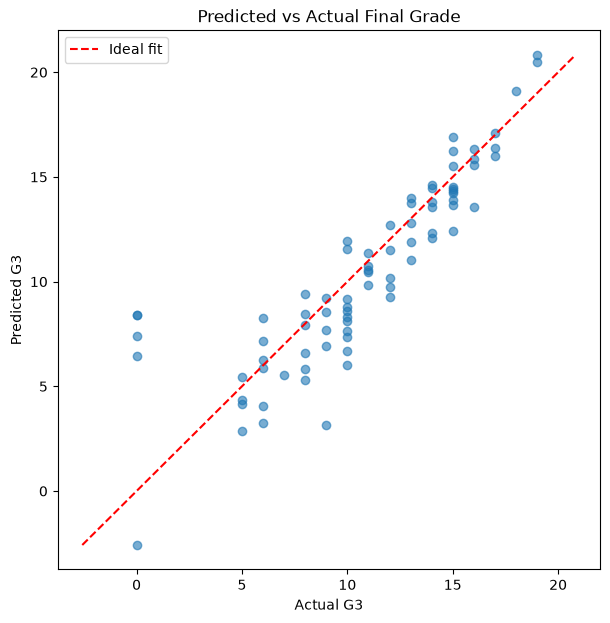

In [22]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.6)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, color="red", linestyle="--", label="Ideal fit")
plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Predicted vs Actual Final Grade")
plt.legend()
plt.show()

## 10. Interpretation of Results

**Convergence behaviour:** With `learning_rate = 0.1`, the training cost drops
from an initial MSE of ~128 (theta = 0) to 1.41 within 1000 iterations, with
almost all of the improvement happening in the first ~100 iterations before
the curve flattens - Batch Gradient Descent has converged for this feature set.
The learning-rate sweep over 200 iterations shows the classic trade-off:
`lr = 0.001` is still decreasing slowly and has not converged in the given
budget, `lr = 0.01`-`0.3` converge smoothly and reach a low cost within
~50-100 iterations, and `lr = 0.5` is on the edge of instability, converging
far more slowly and unevenly than the moderate rates because each step
overshoots the minimum along several dimensions before correcting.

**Prediction performance:** On the held-out test set the model achieves
MAE = 1.65, MSE = 5.66, RMSE = 2.38 and R² = 0.72 - i.e. the model explains
about 72% of the variance in the final grade (`G3`), and predictions are on
average within about 1.6-2.4 grade points (on the 0-20 scale) of the true
value. This performance is driven largely by `G1` and `G2` (the earlier
period grades), which are strongly correlated with `G3`; the remaining
demographic/social/academic features contribute the rest. Overall, gradient
descent successfully finds a set of weights that generalizes reasonably well
from the training set to the test set, confirming that Linear Regression is a
reasonable model for this dataset once categorical features are encoded and
inputs are scaled.